In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Saving bangkok-thailand-august-12-2016-beautiful-luxury-living-room.jpg to bangkok-thailand-august-12-2016-beautiful-luxury-living-room (1).jpg


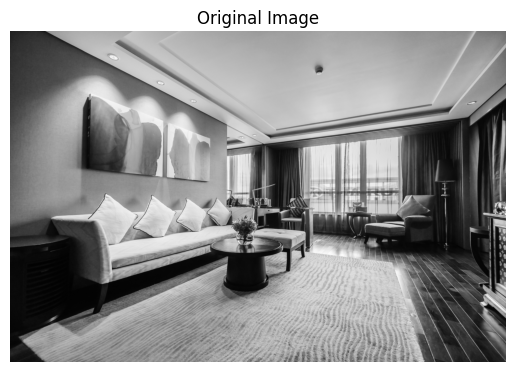

/tmp/ipykernel_459/3396484552.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(image.ravel(), 256, [0,256])
/tmp/ipykernel_459/3396484552.py:32: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0,256])


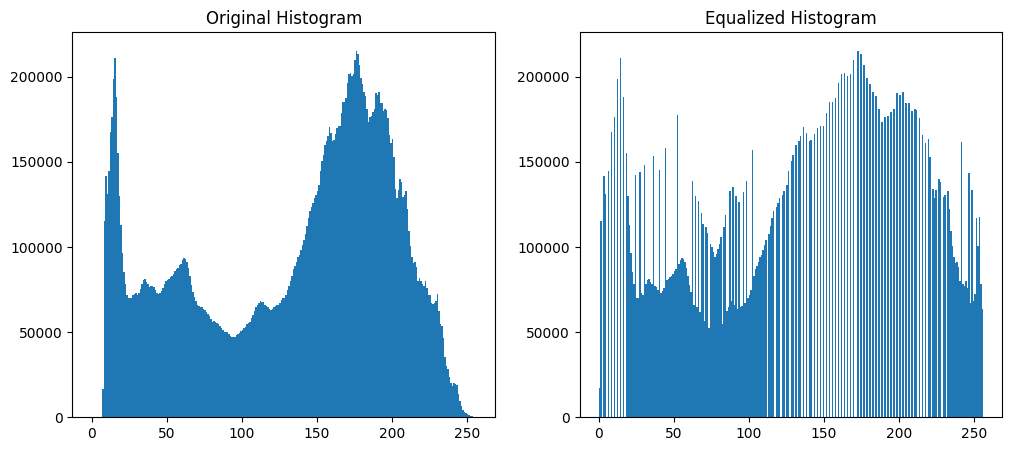

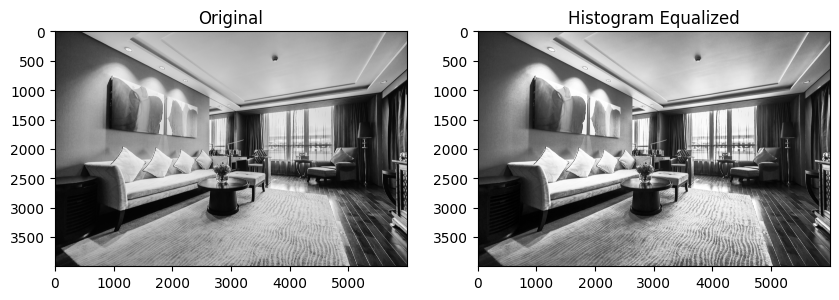

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy
from google.colab import files


uploaded = files.upload()

image_name = list(uploaded.keys())[0]

image = cv2.imread(image_name, cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

equalized = cv2.equalizeHist(image)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(image.ravel(), 256, [0,256])
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(equalized.ravel(), 256, [0,256])
plt.title("Equalized Histogram")

plt.show()

# Image comparison
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray')
plt.title("Histogram Equalized")

plt.show()

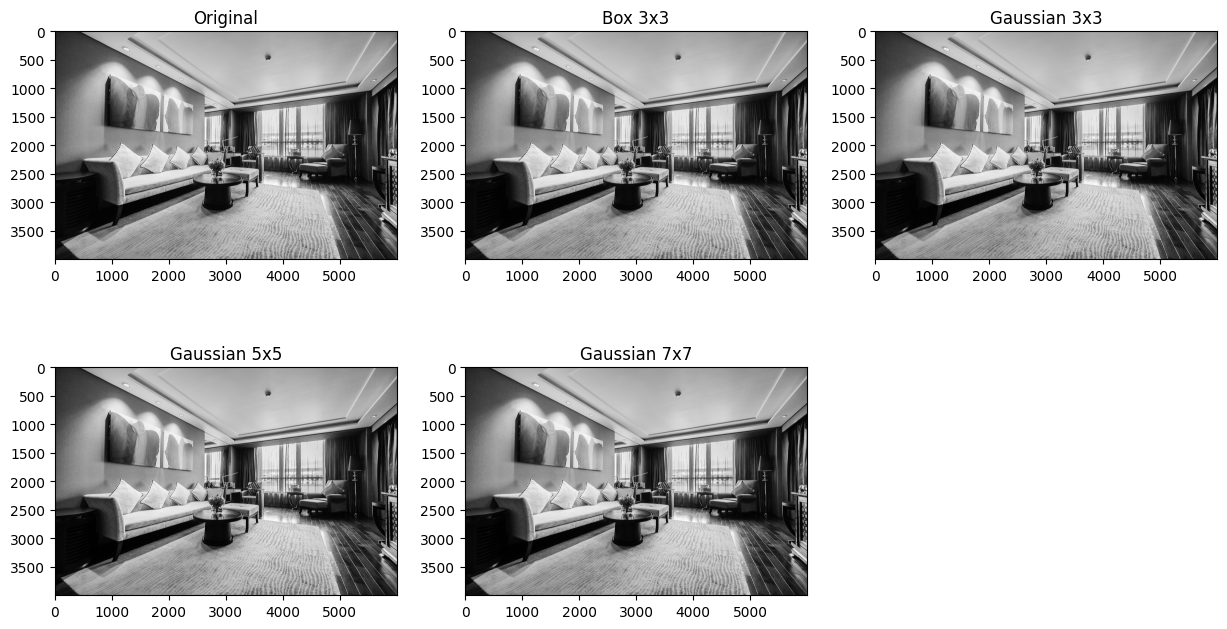

In [3]:
# Box filter function
def box_filt(n):
    kernel = np.ones((n, n), np.float32) / (n*n)
    return kernel

# Gaussian filtering
gauss3 = cv2.GaussianBlur(image, (3,3), 0)
gauss5 = cv2.GaussianBlur(image, (5,5), 0)
gauss7 = cv2.GaussianBlur(image, (7,7), 0)

# Box filter comparison
box3 = cv2.filter2D(image, -1, box_filt(3))

plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(2,3,2)
plt.imshow(box3, cmap='gray')
plt.title("Box 3x3")

plt.subplot(2,3,3)
plt.imshow(gauss3, cmap='gray')
plt.title("Gaussian 3x3")

plt.subplot(2,3,4)
plt.imshow(gauss5, cmap='gray')
plt.title("Gaussian 5x5")

plt.subplot(2,3,5)
plt.imshow(gauss7, cmap='gray')
plt.title("Gaussian 7x7")

plt.show()

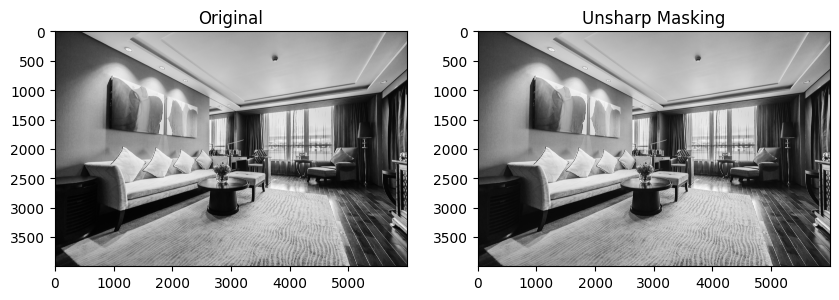

In [4]:
blurred = cv2.GaussianBlur(image, (9,9), 10)

unsharp = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(unsharp, cmap='gray')
plt.title("Unsharp Masking")

plt.show()